# Data Visualization for Cleaned Data without StopWords

# Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import datetime
import seaborn as sns
import numpy as np

import nltk.tokenize
import cufflinks as cf

cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)

C:\Users\Kajal\Anaconda3\lib\site-packages\dask\config.py:168: YAMLLoadWarning:

calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.



# Load the Dataset

In [2]:
f = r'C:\Users\Kajal\Desktop\Fake_News_Project\news\news.csv'
Cleaned_Df = pd.read_csv(f)
Cleaned_Df.drop(Cleaned_Df.columns[Cleaned_Df.columns.str.contains('Unnamed: 0',case = False)],axis = 1, inplace = True)
Cleaned_Df.head()

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


# Check for duplicate rows in a Dataframe

In [3]:
# Check for Duplicate rows in whole DataFrame.
duplicate = Cleaned_Df[Cleaned_Df.duplicated()] 
print("Duplicate rows in the Dataframe:") # There are few duplicates in my dataset.
duplicate

Duplicate rows in the Dataframe:


,title,text,label
1492,"University of Missouri, please immediately fir...",To watch the video of photographer Tim Tai get...,REAL
1954,Loretta Lynch becomes first African-American w...,Washington (CNN) Loretta Lynch was sworn in as...,REAL
2336,Obamacare Enrollees Anxiously Await Supreme Co...,"“I’ve got my six-month, regular cancer checkup...",REAL
2856,Donald Trump is blatantly racist — and the med...,"Donald Trump, the actual Republican candidate ...",REAL
2952,"Black Agenda Report for Week of Oct 31, 2016","News, information and analysis from the black ...",FAKE
3081,The College Loan Bombshell Hidden in the Budget,In obscure data tables buried deep in its 2016...,REAL
3292,This astonishing chart shows how moderate Repu...,Political scientists have known for years that...,REAL
3301,OnPolitics | 's politics blog,Who has Trump appointed to his cabinet so far?...,REAL
3324,Senate GOP prepared to replace Obamacare subsi...,"Killing Obama administration rules, dismantlin...",REAL
4140,We Republicans Lost On Gay Rights. That’s A Go...,I’m not among those Republicans who have “evol...,REAL


In [4]:
# dropping duplicate values 
print("Before removing duplicates, length of data :",len(Cleaned_Df))
Cleaned_Df.drop_duplicates(keep=False,inplace=True) 
print("After dropping duplicate values, length of data :", len(Cleaned_Df))

Before removing duplicates, length of data : 6335
After dropping duplicate values, length of data : 6278


In [5]:
# Convert to lowercase

Cleaned_Df['text'] = Cleaned_Df['text'].apply(lambda x: x.lower())
Cleaned_Df.head()

,title,text,label
0,You Can Smell Hillary’s Fear,"daniel greenfield, a shillman journalism fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,google pinterest digg linkedin reddit stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,u.s. secretary of state john f. kerry said mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— kaydee king (@kaydeeking) november 9, 2016 t...",FAKE
4,The Battle of New York: Why This Primary Matters,it's primary day in new york and front-runners...,REAL


In [6]:
# Remove punctuation

import string

def punctuation_removal(text):
    all_list = [char for char in text if char not in string.punctuation]
    clean_str = ''.join(all_list)
    return clean_str

Cleaned_Df['text'] = Cleaned_Df['text'].apply(punctuation_removal)

In [7]:
# Removing stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('english')

Cleaned_Df['text'] = Cleaned_Df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Kajal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
# Check
Cleaned_Df.head()

,title,text,label
0,You Can Smell Hillary’s Fear,daniel greenfield shillman journalism fellow f...,FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,google pinterest digg linkedin reddit stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,us secretary state john f kerry said monday st...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,— kaydee king kaydeeking november 9 2016 lesso...,FAKE
4,The Battle of New York: Why This Primary Matters,primary day new york frontrunners hillary clin...,REAL


# Check missing values for each column

In [9]:
#Check missing values for each column
Cleaned_Df.isnull().sum().sort_values(ascending=False)  # No missing values in my data.

label    0
text     0
title    0
dtype: int64

In [10]:
# Removing the title (we will only use the text)
Cleaned_Df.drop(['title'],axis=1,inplace=True)
Cleaned_Df.head()

,text,label
0,daniel greenfield shillman journalism fellow f...,FAKE
1,google pinterest digg linkedin reddit stumbleu...,FAKE
2,us secretary state john f kerry said monday st...,REAL
3,— kaydee king kaydeeking november 9 2016 lesso...,FAKE
4,primary day new york frontrunners hillary clin...,REAL


## Basic Data Exploration

### How many articles per Label?

label
FAKE    3140
REAL    3138
Name: text, dtype: int64


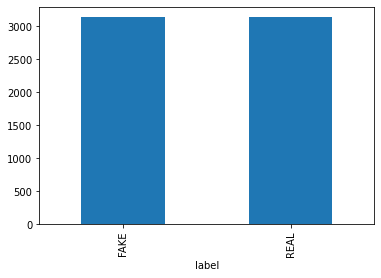

In [11]:
# How many articles per label?
print(Cleaned_Df.groupby(['label'])['text'].count())
Cleaned_Df.groupby(['label'])['text'].count().plot(kind="bar")
plt.show() # Pretty equal amount of articles to each label.

### Word cloud for Fake News

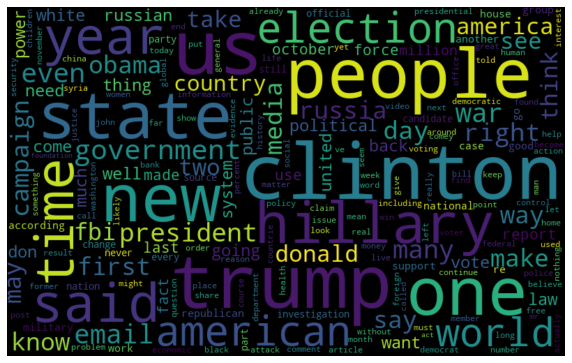

In [12]:
# Word cloud for fake news
from wordcloud import WordCloud

fake_data = Cleaned_Df[Cleaned_Df["label"] == "FAKE"]
all_words = ' '.join([text for text in fake_data.text])

wordcloud = WordCloud(width= 800, height= 500,
                          max_font_size = 110,
                          collocations = False).generate(all_words)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### Word cloud for Real News

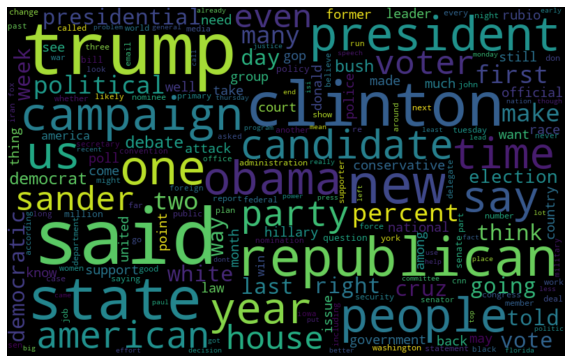

In [13]:
# Word cloud for real news
from wordcloud import WordCloud

real_data = Cleaned_Df[Cleaned_Df["label"] == "REAL"]
all_words = ' '.join([text for text in real_data.text])

wordcloud = WordCloud(width= 800, height= 500,
                          max_font_size = 110,
                          collocations = False).generate(all_words)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### Frequent Words Counter

In [14]:
# Most frequent words counter (Code adapted from https://www.kaggle.com/rodolfoluna/fake-news-detector)   
from nltk import tokenize

token_space = tokenize.WhitespaceTokenizer()

def counter(text, column_text, quantity):
    all_words = ' '.join([text for text in text[column_text]])
    token_phrase = token_space.tokenize(all_words)
    frequency = nltk.FreqDist(token_phrase)
    df_frequency = pd.DataFrame({"Word": list(frequency.keys()),
                                   "Frequency": list(frequency.values())})
    df_frequency = df_frequency.nlargest(columns = "Frequency", n = quantity)
    plt.figure(figsize=(12,8))
    ax = sns.barplot(data = df_frequency, x = "Word", y = "Frequency", color = 'blue')
    ax.set(ylabel = "Count")
    plt.xticks(rotation='vertical')
    plt.show()

### Frequent word counters in Fake News

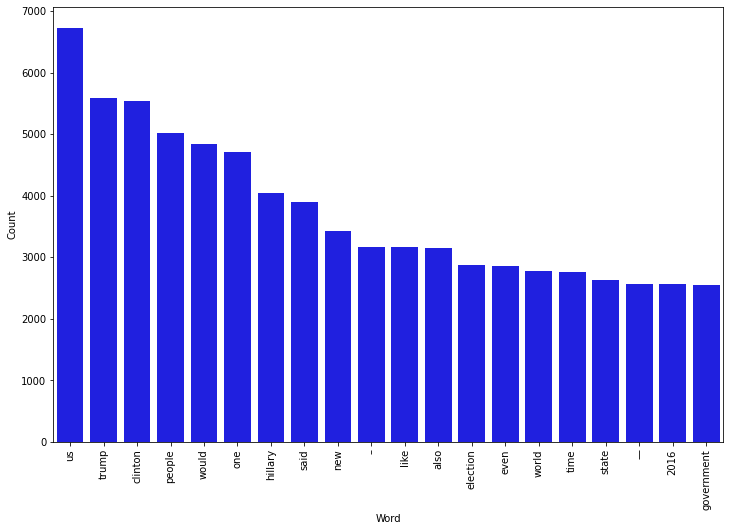

In [15]:
# Most frequent words in fake news
counter(Cleaned_Df[Cleaned_Df["label"] == "FAKE"], "text", 20)

### Frequent Word Counters in Real News

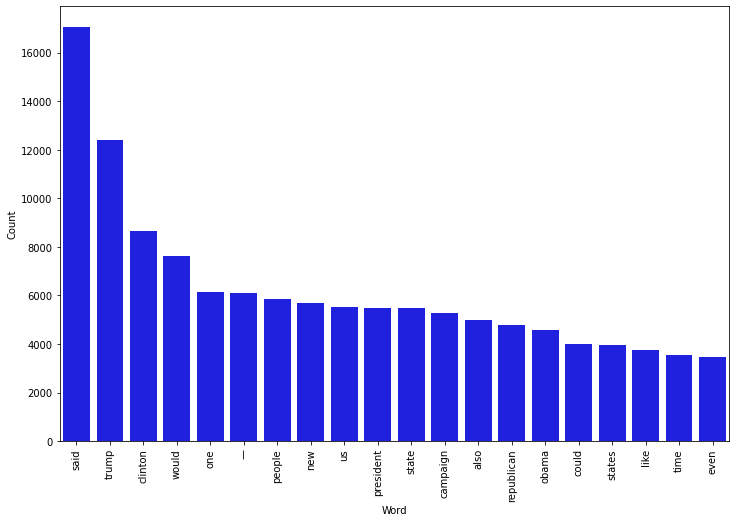

In [16]:
# Most frequent words in fake news
counter(Cleaned_Df[Cleaned_Df["label"] == "REAL"], "text", 20)

## Summary:
- Without stopwords file is giving us good sense of important key-terms in our data corresponding to each Label.
- It might not be the case with stopwords file, to check out the results, take a look at 2nd file of visualization with having stopwords in it.